# Figure S1 -- Grid search over model hyperparameters (MSE)

Visualizes the Ridge-regression MSE grid search over pooling method (avg/max), activation
function (ReLU/sigmoid), motif-aggregation method (mean/max), activation threshold, and
ridge alpha, for both the position-independent (700 bp bin) and position-dependent
(100 bp bin) LogFC models (Methods 2.4-2.5). The optimum for each of the 8
pooling/activation/motif-agg combinations is boxed in blue.

**Required inputs** (place in `../output_files/`): one `RidgeCV_3outputs_gridsearch_results_
bin{700,100}bp_{avg,max}pooling_{relu,sigmoid}_S0.pkl` file for each of the 4
pooling/activation combinations at each bin length (8 files total), produced by running
`grid_search.py` with the full activation-threshold and motif-aggregation sweep.

In [1]:
import os
import glob
import itertools
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
import seaborn as sns

OUTPUT_DIR = '../output_files'
FIGURES_DIR = '../figures'
INPUT_DIR = '../input_files'
os.makedirs(FIGURES_DIR, exist_ok=True)

pool_functions = ['avg', 'max']
activation_functions = ['relu', 'sigmoid']
motif_agg_methods = ['avg', 'max']
strand_agg = 'sum'  # S0 -- single-strand aggregation used throughout the main text
S = 'S0'
n_mots = 647

relu_list = np.arange(-2, 18, 2)
alpha_list = [0] + np.logspace(-1, 6, 15, base=10).tolist()

c:\Users\Hoda Taeb\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def find_best_config(bin_len, relu_list, metric_name='MSE', output='lfc'):
    """Load the cached grid-search results for every pooling/activation combo at this
    bin length, and report the best (relu_thr, alpha) configuration for each of the
    8 pooling/activation/motif-agg combinations, plus the single overall best."""
    metric = 0 if metric_name == 'MSE' else (1 if metric_name == 'PCC' else 2)
    all_results = {}
    for pool_f, act_f in itertools.product(pool_functions, activation_functions):
        # Glob with an optional prefix: cached results may be shipped as
        # "Converted_..." (re-pickled under a different numpy version for
        # portability) or produced fresh (no prefix) by running grid_search.py.
        pattern = f'{OUTPUT_DIR}/*RidgeCV_3outputs_gridsearch_results_bin{bin_len}bp_{pool_f}pooling_{act_f}_{S}.pkl'
        matches = glob.glob(pattern)
        if not matches:
            raise FileNotFoundError(
                f"No grid-search results found matching {pattern}. "
                "Run grid_search.py with the full activation-threshold/motif-agg sweep first."
            )
        with open(matches[0], 'rb') as f:
            results = pickle.load(f)
        for key, value in results['results'].items():
            all_results.setdefault(key, []).append(value)

    alphas = np.array(results['alphas'])
    heatmap_data = np.zeros((8, len(relu_list), 5, len(alphas)))
    c = 0
    for pool_f, act_f, motif_agg in itertools.product(pool_functions, activation_functions, motif_agg_methods):
        for i, relu_thr in enumerate(relu_list):
            heatmap_data[c, i, :, :] = all_results[(relu_thr, pool_f, act_f, strand_agg, motif_agg)][0][output][metric]
        c += 1

    sub_plots = np.mean(heatmap_data, axis=2)  # average over the 5 CV folds

    combos = list(itertools.product(['AvgPooling', 'MaxPooling'], ['ReLU', 'Sigmoid'], ['Motifs_mean', 'Motifs_max']))
    opt_values = np.min(sub_plots, axis=(1, 2)) if metric_name == 'MSE' else np.max(sub_plots, axis=(1, 2))
    flat_idx = np.argmin(sub_plots.reshape(8, -1), axis=1) if metric_name == 'MSE' else np.argmax(sub_plots.reshape(8, -1), axis=1)
    rows, cols = np.unravel_index(flat_idx, (len(relu_list), len(alphas)))

    for i in range(8):
        print(f"{combos[i]}: Optimum={opt_values[i]:.4f} at Act_thr{relu_list[rows[i]]}, Alpha={alphas[cols[i]]}")

    best_i = np.argmin(opt_values) if metric_name == 'MSE' else np.argmax(opt_values)
    best_pooling, best_act_func, best_motif_agg = combos[best_i]
    best_act_thr = float(relu_list[rows[best_i]])
    best_alpha = float(alphas[cols[best_i]])
    best_cv_metric = float(opt_values[best_i])
    print(f"Overall best configuration for bin{bin_len}bp-{S}-{output}: {combos[best_i]} "
          f"with Optimum={best_cv_metric:.4f} at Act_thr{best_act_thr}, Alpha={best_alpha}")

    best_config = {
        'pooling': best_pooling,
        'activation_function': best_act_func,
        'activaition_threshold': best_act_thr,
        'motif_agg_method': best_motif_agg,
        'alpha_value': best_alpha,
        f'cv_{metric_name.lower()}': best_cv_metric,
    }
    return sub_plots, alphas, best_config


def plot_heatmaps_MSE(sub_plots, alpha_list, relu_list, output='lfc', metric_name='MSE',
                       vmin_max=(0.2125, 0.230), title=''):
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten()
    combos = list(itertools.product(['AvgPooling', 'MaxPooling'], ['ReLU', 'Sigmoid'], ['Motifs_mean', 'Motifs_max']))
    for i, data in enumerate(sub_plots):
        sns.heatmap(data, xticklabels=alpha_list, yticklabels=relu_list, cmap='hot',
                    vmin=vmin_max[0], vmax=vmin_max[1], ax=axes[i], cbar=True)
        opt_y, opt_x = (np.unravel_index(np.argmin(data, axis=None), data.shape) if metric_name == 'MSE'
                        else np.unravel_index(np.argmax(data, axis=None), data.shape))
        axes[i].add_patch(patches.Rectangle((opt_x, opt_y), 1, 1, edgecolor='blue', facecolor='none',
                                             linewidth=3, clip_on=False))
        axes[i].set_title(f'{combos[i][0]}, {combos[i][1]}, {combos[i][2]}', fontsize=16)
        axes[i].set_xlabel('Alpha Values', fontsize=14)
        axes[i].set_ylabel('ReLU Thresholds', fontsize=14)
        labels = [0] + [f'$10^{{{np.log10(a)}}}$' for a in alpha_list[1:]]
        axes[i].set_xticklabels(labels, rotation=45, ha='right')

    plt.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/figS1_{title.replace(' ', '_').replace('(', '').replace(')', '')}_heatmaps.pdf", bbox_inches='tight')
    fig.savefig(f"{FIGURES_DIR}/figS1_{title.replace(' ', '_').replace('(', '').replace(')', '')}_heatmaps.svg", bbox_inches='tight')
    plt.show()

## Figure S1 -- MSE heatmaps, position-independent (700 bp) and position-dependent (100 bp) models

Processing bin length: 700bp
('AvgPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2123 at Act_thr6, Alpha=1.0
('AvgPooling', 'ReLU', 'Motifs_max'): Optimum=0.2133 at Act_thr8, Alpha=1.0
('AvgPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2135 at Act_thr8, Alpha=0.1
('AvgPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2143 at Act_thr10, Alpha=0.1
('MaxPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2124 at Act_thr6, Alpha=316227.7660168379
('MaxPooling', 'ReLU', 'Motifs_max'): Optimum=0.2130 at Act_thr8, Alpha=316227.7660168379
('MaxPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2125 at Act_thr10, Alpha=3162.2776601683795
('MaxPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2134 at Act_thr14, Alpha=1000.0
Overall best configuration for bin700bp-S0-lfc: ('AvgPooling', 'ReLU', 'Motifs_mean') with Optimum=0.2123 at Act_thr6.0, Alpha=1.0


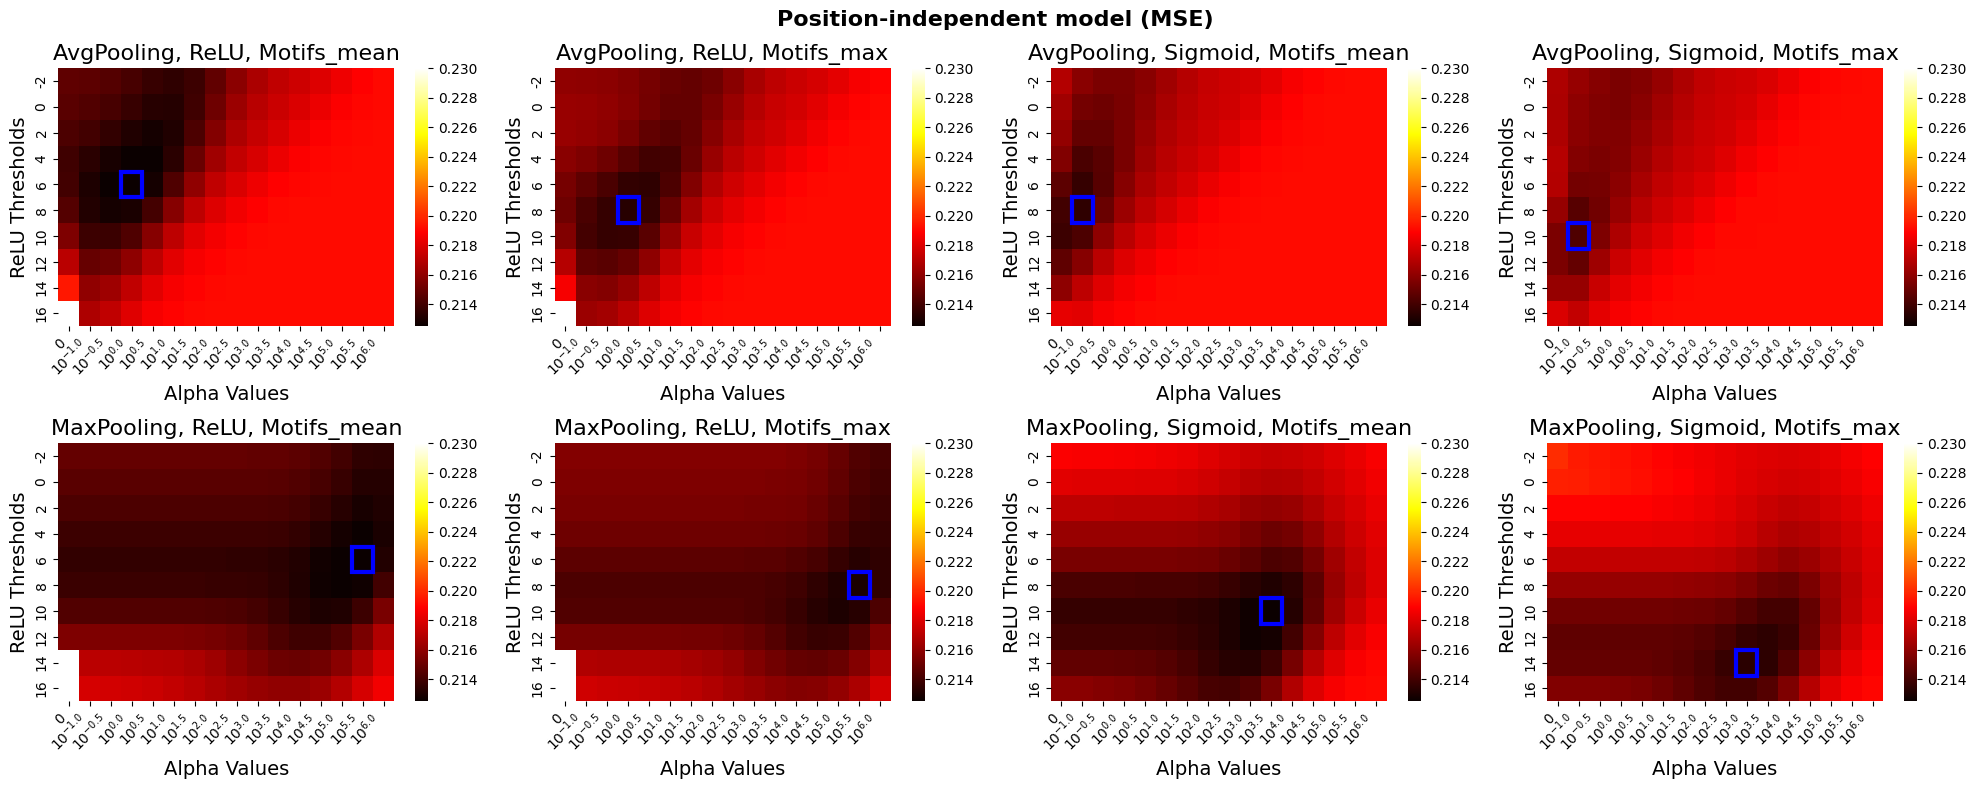

Processing bin length: 100bp
('AvgPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2129 at Act_thr6, Alpha=31.622776601683793
('AvgPooling', 'ReLU', 'Motifs_max'): Optimum=0.2132 at Act_thr8, Alpha=31.622776601683793
('AvgPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2130 at Act_thr10, Alpha=0.31622776601683794
('AvgPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2135 at Act_thr12, Alpha=0.31622776601683794
('MaxPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2128 at Act_thr6, Alpha=100000.0
('MaxPooling', 'ReLU', 'Motifs_max'): Optimum=0.2129 at Act_thr8, Alpha=100000.0
('MaxPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2131 at Act_thr12, Alpha=1000.0
('MaxPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2134 at Act_thr12, Alpha=3162.2776601683795
Overall best configuration for bin100bp-S0-lfc: ('MaxPooling', 'ReLU', 'Motifs_mean') with Optimum=0.2128 at Act_thr6.0, Alpha=100000.0


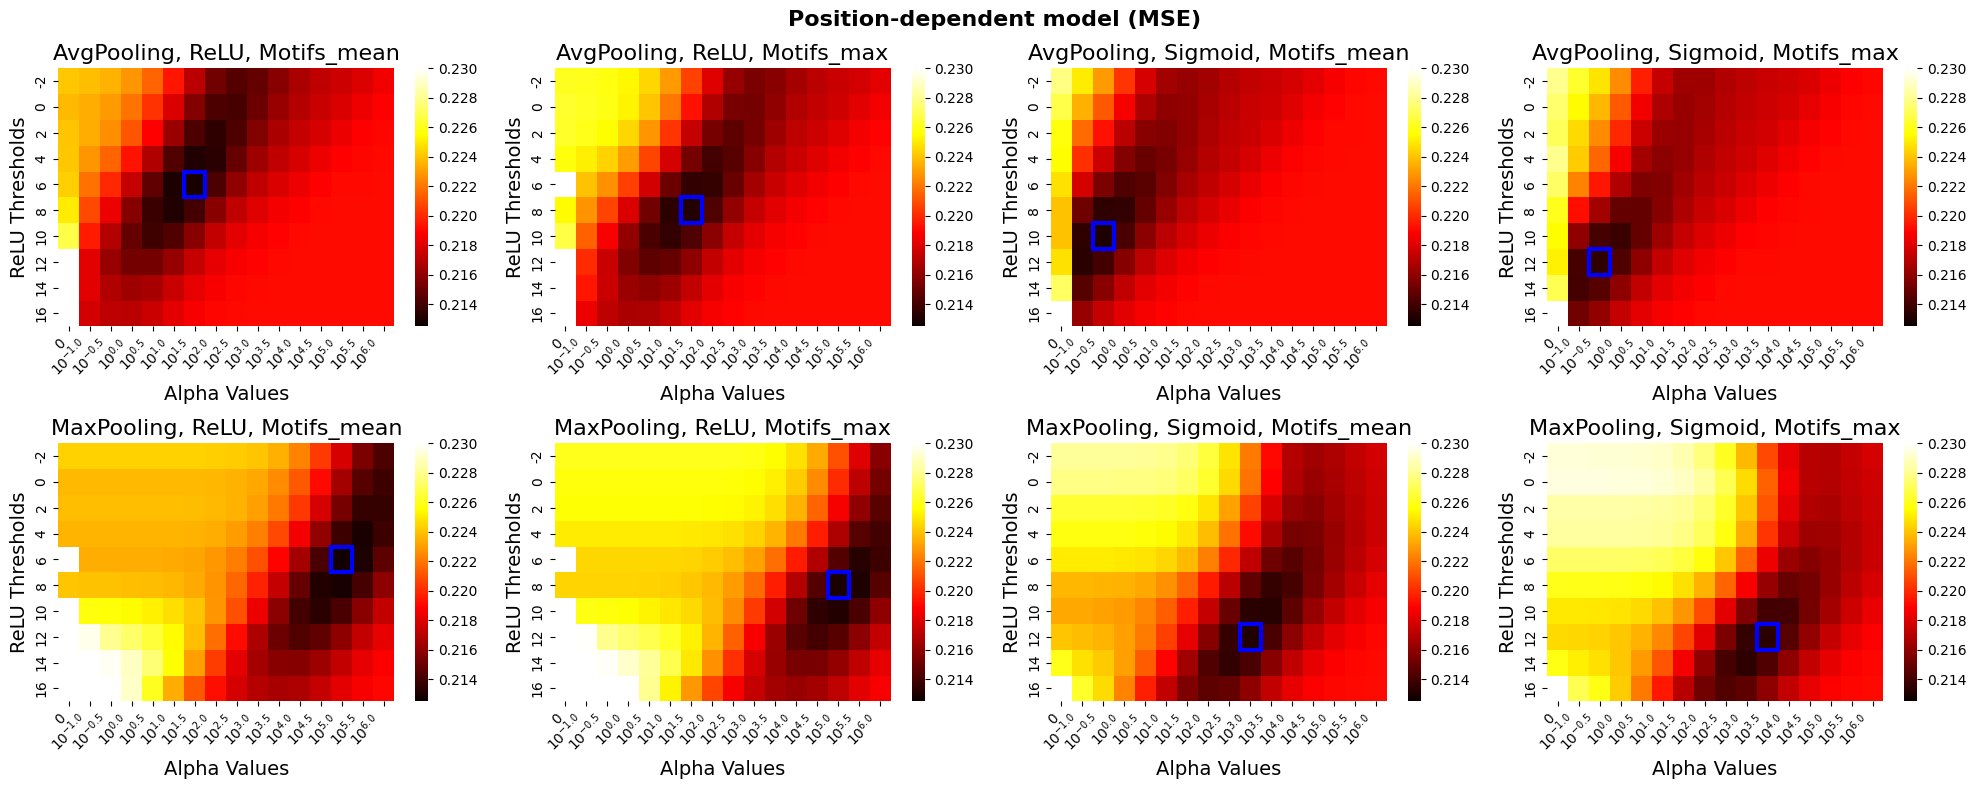

In [3]:
vmin_max = (0.2125, 0.230)  # lfc
output_ = 'lfc'
titles = ['Position-independent model (MSE)', 'Position-dependent model (MSE)']

for bin_len, title in zip([700, 100], titles):
    print(f"Processing bin length: {bin_len}bp")
    sub_plots, alphas, _ = find_best_config(bin_len=bin_len, relu_list=relu_list, metric_name='MSE', output=output_)
    plot_heatmaps_MSE(sub_plots, alphas, relu_list, output=output_, metric_name='MSE', vmin_max=vmin_max, title=title)

## Best-config JSON for train_model_pipeline.py

Finds the best (pooling, activation, activation threshold, motif-agg, alpha) configuration
for each of lfc/dht/etoh at both bin lengths (6 models total) and writes
`../input_files/best_models_hyperparams_MSE_647mots.json`, keyed by `{bin_len}bp_S0_{output}`
-- the file `train_model_pipeline.py` needs to train each final model.

In [4]:
best_models = {}
for bin_len in [700, 100]:
    for output_ in ['lfc', 'dht', 'etoh']:
        print(f"--- bin{bin_len}bp, {output_} ---")
        _, _, best_config = find_best_config(bin_len=bin_len, relu_list=relu_list, metric_name='MSE', output=output_)
        best_models[f'{bin_len}bp_S0_{output_}'] = best_config

with open(f'{INPUT_DIR}/best_models_hyperparams_MSE_{n_mots}mots.json', 'w') as f:
    json.dump(best_models, f, indent=2)
print(f"\nWrote best configs for {len(best_models)} models to best_models_hyperparams_MSE_{n_mots}mots.json")

--- bin700bp, lfc ---
('AvgPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2123 at Act_thr6, Alpha=1.0
('AvgPooling', 'ReLU', 'Motifs_max'): Optimum=0.2133 at Act_thr8, Alpha=1.0
('AvgPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2135 at Act_thr8, Alpha=0.1
('AvgPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2143 at Act_thr10, Alpha=0.1
('MaxPooling', 'ReLU', 'Motifs_mean'): Optimum=0.2124 at Act_thr6, Alpha=316227.7660168379
('MaxPooling', 'ReLU', 'Motifs_max'): Optimum=0.2130 at Act_thr8, Alpha=316227.7660168379
('MaxPooling', 'Sigmoid', 'Motifs_mean'): Optimum=0.2125 at Act_thr10, Alpha=3162.2776601683795
('MaxPooling', 'Sigmoid', 'Motifs_max'): Optimum=0.2134 at Act_thr14, Alpha=1000.0
Overall best configuration for bin700bp-S0-lfc: ('AvgPooling', 'ReLU', 'Motifs_mean') with Optimum=0.2123 at Act_thr6.0, Alpha=1.0
--- bin700bp, dht ---
('AvgPooling', 'ReLU', 'Motifs_mean'): Optimum=1.2925 at Act_thr6, Alpha=0.31622776601683794
('AvgPooling', 'ReLU', 'Motifs_max'): Optimum=1.3283 at Act